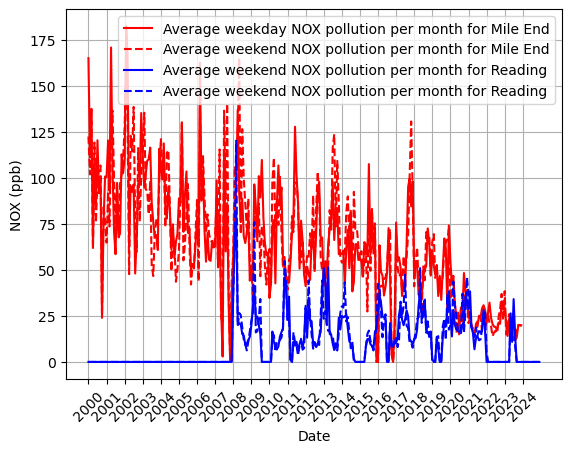

In [1]:
from datetime import datetime
from matplotlib import pyplot as plt
def readDataByDate(f, startDate, endDate, species):
    lines = []
    dates = []
    values = []
    for i in f:
        strippedline = i.rstrip('\n')
        fields = strippedline.split(',')
        if fields[1] == species:
            lines.append(fields)
    for i in lines:
        dateandtime = i[2]
        value = i[3]
        date = datetime.strptime(dateandtime, "%d/%m/%Y %H:%M")
        strpstart = datetime.strptime(startDate, "%d/%m/%Y %H:%M")
        strpend = datetime.strptime(endDate, "%d/%m/%Y %H:%M")
        if date < strpstart:
            continue
        elif value == '':
            values.append(0)
            continue
        elif date > strpend:
            break
        else:
            dates.append(date)      
        values.append(float(value))
    return dates,values
            
def averageByWeekMonthly(dates, values, month, year):
    weekdayentry = [0]*5
    weekdaytotal = [0]*5
    weekendentry = [0]*2
    weekendtotal = [0]*2
    for i,j in zip(dates, values):
        if i.month == month and i.year == year:
            weekdaynumber = i.weekday()
            if weekdaynumber < 5:
                weekdayentry[weekdaynumber] += 1
                weekdaytotal[weekdaynumber] += j
            else:
                weekendindex = weekdaynumber - 5
                weekendentry[weekendindex] += 1
                weekendtotal[weekendindex] += j
    weekdayoutput = []
    weekendoutput = []
    for i,j in zip(weekdayentry,weekdaytotal):
        if i == 0:
            weekdayoutput.append(0)
        else:
            weekdayoutput.append(j/i)
    for i,j in zip(weekendentry,weekendtotal):
        if i == 0:
            weekendoutput.append(0)
        else:
            weekendoutput.append(j/i)
    weekdayaverage = sum(weekdayoutput)/len(weekdayoutput)
    weekendaverage = sum(weekendoutput)/len(weekendoutput)
    return weekdayaverage,weekendaverage

f = open('LaqnData-MileEnd_2000_2009.csv', 'r')
g = open('LaqnData-MileEnd_2010_2019.csv', 'r')
h = open('LaqnData-MileEnd_2020_2025.csv', 'r')
headers = f.readline()
headers = g.readline()
headers = h.readline()

alldates = []
allvalues = []

dates1, values1 = readDataByDate(f, '01/01/2000 00:00', '31/12/2009 23:59', 'NOX')
alldates.extend(dates1)
allvalues.extend(values1)
dates2, values2 = readDataByDate(g, '01/01/2010 00:00', '31/12/2019 23:59', 'NOX')
alldates.extend(dates2)
allvalues.extend(values2)
dates3, values3 = readDataByDate(h, '01/01/2020 00:00', '31/12/2024 23:59', 'NOX')
alldates.extend(dates3)
allvalues.extend(values3)

weekdays = []
weekends = []
axisdates = []
for i in range(2000,2024):
    for j in range(1,13):
        axisdates.append(datetime(i,j,15))
        weekday,weekend = averageByWeekMonthly(alldates, allvalues, j, i)
        weekdays.append(weekday)
        weekends.append(weekend)
        
plt.plot(axisdates,weekdays,'r-', label='Average weekday NOX pollution per month for Mile End')
plt.plot(axisdates,weekends,'r--', label='Average weekend NOX pollution per month for Mile End')

l = open('LaqnData-Reading_2000_2009.csv', 'r')
m = open('LaqnData-Reading_2010_2019.csv', 'r')
n = open('LaqnData-Reading_2020_2024.csv', 'r')
headers = l.readline()
headers = m.readline()
headers = n.readline()

alldatesR = []
allvaluesR = []

dates4, values4 = readDataByDate(l, '01/01/2000 00:00', '31/12/2009 23:59', 'NOX')
alldatesR.extend(dates4)
allvaluesR.extend(values4)
dates5, values5 = readDataByDate(m, '01/01/2010 00:00', '31/12/2019 23:59', 'NOX')
alldatesR.extend(dates5)
allvaluesR.extend(values5)
dates6, values6 = readDataByDate(n, '01/01/2020 00:00', '31/12/2024 23:59', 'NOX')
alldatesR.extend(dates6)
allvaluesR.extend(values6)   

weekdaysR = []
weekendsR = []
axisdatesR = []
for i in range(2000,2025):
    for j in range(1,13):
        axisdatesR.append(datetime(i,j,15))
        weekdayR,weekendR = averageByWeekMonthly(alldatesR, allvaluesR, j, i)
        weekdaysR.append(weekdayR)
        weekendsR.append(weekendR)
        
plt.plot(axisdatesR,weekdaysR,'b-', label='Average weekend NOX pollution per month for Reading')
plt.plot(axisdatesR,weekendsR,'b--', label='Average weekend NOX pollution per month for Reading')
plt.xticks([datetime(year, 1, 15) for year in range(2000, 2025)], [str(year) for year in range(2000, 2025)], rotation=45)

plt.grid(True)
plt.xlabel('Date')
plt.ylabel('NOX (ppb)')  
plt.legend()

#I will use data between 2012 and 2018 as that part of the plot has the most data from both Mile End and Reading, allowing a better comparison as some points show 0 which is not a fair comparison.


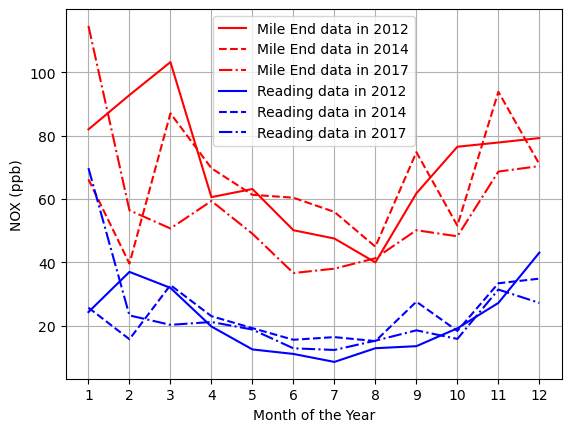

In [2]:
#2012, 2014, 2018

file2012 = open('LaqnData-MileEnd_2010_2019.csv', 'r')
headers = file2012.readline()
alldates2012 = []
allvalues2012 = []
weekdays2012 = []
weekends2012 = []

dates2012, values2012 = readDataByDate(file2012, '01/01/2012 00:00', '31/12/2012 23:59', 'NOX')
alldates2012.extend(dates2012)
allvalues2012.extend(values2012)
for i in range(1,13):
    weekday2012, weekend2012 = averageByWeekMonthly(alldates2012, allvalues2012, i, 2012)
    weekdays2012.append(weekday2012)
    weekends2012.append(weekend2012)
plt.plot(range(1,13), weekdays2012, 'r-', label='Mile End data in 2012')


file2014 = open('LaqnData-MileEnd_2010_2019.csv', 'r')
alldates2014 = []
allvalues2014 = []
weekdays2014 = []
weekends2014 = []
dates2014, values2014 = readDataByDate(file2014, '01/01/2014 00:00', '31/12/2014 23:59', 'NOX')
alldates2014.extend(dates2014)
allvalues2014.extend(values2014)
for i in range(1,13):
    weekday2014, weekend2014 = averageByWeekMonthly(alldates2014, allvalues2014, i, 2014)
    weekdays2014.append(weekday2014)
    weekends2014.append(weekend2014)
plt.plot(range(1,13), weekdays2014, 'r--', label='Mile End data in 2014')


file2017 = open('LaqnData-MileEnd_2010_2019.csv', 'r')
alldates2017 = []
allvalues2017 = []
weekdays2017 = []
weekends2017 = []
dates2017, values2017 = readDataByDate(file2017, '01/01/2017 00:00', '31/12/2017 23:59', 'NOX')
alldates2017.extend(dates2017)
allvalues2017.extend(values2017)
for i in range(1,13):
    weekday2017, weekend2017 = averageByWeekMonthly(alldates2017, allvalues2017, i, 2017)
    weekdays2017.append(weekday2017)
    weekends2017.append(weekend2017)
plt.plot(range(1,13), weekdays2017, 'r-.', label='Mile End data in 2017')


fileR2012 = open('LaqnData-Reading_2010_2019.csv', 'r')
headers = fileR2012.readline()
alldatesR2012 = []
allvaluesR2012 = []
weekdaysR2012 = []
weekendsR2012 = []
datesR2012, valuesR2012 = readDataByDate(fileR2012, '01/01/2012 00:00', '31/12/2012 23:59', 'NOX')
alldatesR2012.extend(datesR2012)
allvaluesR2012.extend(valuesR2012)
for i in range(1,13):
    weekdayR2012, weekendR2012 = averageByWeekMonthly(alldatesR2012, allvaluesR2012, i, 2012)
    weekdaysR2012.append(weekdayR2012)
    weekendsR2012.append(weekendR2012)
plt.plot(range(1,13), weekdaysR2012, 'b-', label='Reading data in 2012')


fileR2014 = open('LaqnData-Reading_2010_2019.csv', 'r')
alldatesR2014 = []
allvaluesR2014 = []
weekdaysR2014 = []
weekendsR2014 = []
datesR2014, valuesR2014 = readDataByDate(fileR2014, '01/01/2014 00:00', '31/12/2014 23:59', 'NOX')
alldatesR2014.extend(datesR2014)
allvaluesR2014.extend(valuesR2014)
for i in range(1,13):
    weekdayR2014, weekendR2014 = averageByWeekMonthly(alldatesR2014, allvaluesR2014, i, 2014)
    weekdaysR2014.append(weekdayR2014)
    weekendsR2014.append(weekendR2014)
plt.plot(range(1,13), weekdaysR2014, 'b--', label='Reading data in 2014')


fileR2017 = open('LaqnData-Reading_2010_2019.csv', 'r')
alldatesR2017 = []
allvaluesR2017 = []
weekdaysR2017 = []
weekendsR2017 = []
datesR2017, valuesR2017 = readDataByDate(fileR2017, '01/01/2017 00:00', '31/12/2017 23:59', 'NOX')
alldatesR2017.extend(datesR2017)
allvaluesR2017.extend(valuesR2017)
for i in range(1,13):
    weekdayR2017, weekendR2017 = averageByWeekMonthly(alldatesR2017, allvaluesR2017, i, 2017)
    weekdaysR2017.append(weekdayR2017)
    weekends2017.append(weekendR2017)
plt.plot(range(1,13), weekdaysR2017, 'b-.', label='Reading data in 2017')

plt.grid(True)
plt.xticks(range(1,13,1))
plt.xlabel('Month of the Year')
plt.ylabel('NOX (ppb)')  
plt.legend()

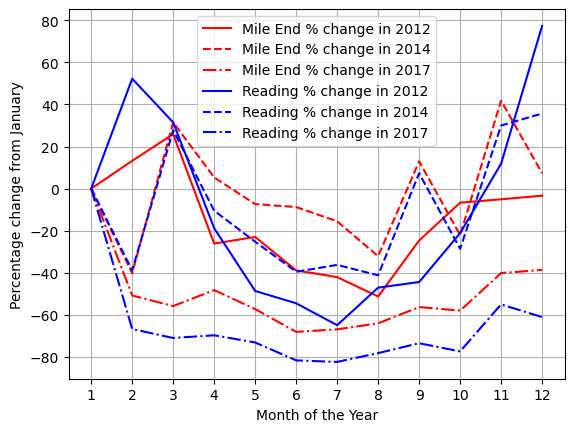

In [3]:
file2012p = open('LaqnData-MileEnd_2010_2019.csv', 'r')
file2012Jan = open('LaqnData-MileEnd_2010_2019.csv', 'r')
headers = file2012p.readline()
headers = file2012Jan.readline()
alldates2012p = []
allvalues2012p = []
weekdays2012p = []
weekends2012p = []
percentage2012values = []
datesJan2012, valuesJan2012 = readDataByDate(file2012Jan, '01/01/2012 00:00', '31/01/2012 23:59', 'NOX')
weekdayJan2012, weekendJan2012 = averageByWeekMonthly(datesJan2012, valuesJan2012, 1, 2012)
dates2012p, values2012p = readDataByDate(file2012p, '01/01/2012 00:00', '31/12/2012 23:59', 'NOX')
alldates2012p.extend(dates2012p)
allvalues2012p.extend(values2012p)
for i in range(1,13):
    weekday2012p, weekend2012p = averageByWeekMonthly(alldates2012p, allvalues2012p, i, 2012)
    percentage2012 = ((weekday2012p - weekdayJan2012)/weekdayJan2012)*100
    percentage2012values.append(percentage2012)
plt.plot(range(1,13), percentage2012values, 'r-', label='Mile End % change in 2012')

file2014p = open('LaqnData-MileEnd_2010_2019.csv', 'r')
file2014Jan = open('LaqnData-MileEnd_2010_2019.csv', 'r')
headers = file2014p.readline()
headers = file2014Jan.readline()
alldates2014p = []
allvalues2014p = []
weekdays2014p = []
weekends2014p = []
percentage2014values = []
datesJan2014, valuesJan2014 = readDataByDate(file2014Jan, '01/01/2014 00:00', '31/01/2014 23:59', 'NOX')
weekdayJan2014, weekendJan2014 = averageByWeekMonthly(datesJan2014, valuesJan2014, 1, 2014)
dates2014p, values2014p = readDataByDate(file2014p, '01/01/2014 00:00', '31/12/2014 23:59', 'NOX')
alldates2014p.extend(dates2014p)
allvalues2014p.extend(values2014p)
for i in range(1,13):
    weekday2014p, weekend2014p = averageByWeekMonthly(alldates2014p, allvalues2014p, i, 2014)
    percentage2014 = ((weekday2014p - weekdayJan2014)/weekdayJan2014)*100
    percentage2014values.append(percentage2014)
plt.plot(range(1,13), percentage2014values, 'r--', label='Mile End % change in 2014')

file2017p = open('LaqnData-MileEnd_2010_2019.csv', 'r')
file2017Jan = open('LaqnData-MileEnd_2010_2019.csv', 'r')
headers = file2017p.readline()
headers = file2017Jan.readline()
alldates2017p = []
allvalues2017p = []
weekdays2017p = []
weekends2014p = []
percentage2017values = []
datesJan2017, valuesJan2017 = readDataByDate(file2017Jan, '01/01/2017 00:00', '31/01/2017 23:59', 'NOX')
weekdayJan2017, weekendJan2017 = averageByWeekMonthly(datesJan2017, valuesJan2017, 1, 2017)
dates2017p, values2017p = readDataByDate(file2017p, '01/01/2017 00:00', '31/12/2017 23:59', 'NOX')
alldates2017p.extend(dates2017p)
allvalues2017p.extend(values2017p)
for i in range(1,13):
    weekday2017p, weekend2017p = averageByWeekMonthly(alldates2017p, allvalues2017p, i, 2017)
    percentage2017 = ((weekday2017p - weekdayJan2017)/weekdayJan2017)*100
    percentage2017values.append(percentage2017)
plt.plot(range(1,13), percentage2017values, 'r-.', label='Mile End % change in 2017')


file2012Rp = open('LaqnData-Reading_2010_2019.csv', 'r')
file2012RJan = open('LaqnData-Reading_2010_2019.csv', 'r')
headers = file2012Rp.readline()
headers = file2012RJan.readline()
alldates2012Rp = []
allvalues2012Rp = []
weekdays2012Rp = []
weekends2012Rp = []
percentage2012Rvalues = []
datesJan2012R, valuesJan2012R = readDataByDate(file2012RJan, '01/01/2012 00:00', '31/01/2012 23:59', 'NOX')
weekdayJan2012R, weekendJan2012R = averageByWeekMonthly(datesJan2012R, valuesJan2012R, 1, 2012)
dates2012Rp, values2012Rp = readDataByDate(file2012Rp, '01/01/2012 00:00', '31/12/2012 23:59', 'NOX')
alldates2012Rp.extend(dates2012Rp)
allvalues2012Rp.extend(values2012Rp)
for i in range(1,13):
    weekday2012Rp, weekend2012Rp = averageByWeekMonthly(alldates2012Rp, allvalues2012Rp, i, 2012)
    percentage2012R = ((weekday2012Rp - weekdayJan2012R)/weekdayJan2012R)*100
    percentage2012Rvalues.append(percentage2012R)
plt.plot(range(1,13), percentage2012Rvalues, 'b-', label='Reading % change in 2012')

file2014Rp = open('LaqnData-Reading_2010_2019.csv', 'r')
file2014RJan = open('LaqnData-Reading_2010_2019.csv', 'r')
headers = file2014Rp.readline()
headers = file2014RJan.readline()
alldates2014Rp = []
allvalues2014Rp = []
weekdays2014Rp = []
weekends2014Rp = []
percentage2014Rvalues = []
datesJan2014R, valuesJan2014R = readDataByDate(file2014RJan, '01/01/2014 00:00', '31/01/2014 23:59', 'NOX')
weekdayJan2014R, weekendJan2014R = averageByWeekMonthly(datesJan2014R, valuesJan2014R, 1, 2014)
dates2014Rp, values2014Rp = readDataByDate(file2014Rp, '01/01/2014 00:00', '31/12/2014 23:59', 'NOX')
alldates2014Rp.extend(dates2014Rp)
allvalues2014Rp.extend(values2014Rp)
for i in range(1,13):
    weekday2014Rp, weekend2014Rp = averageByWeekMonthly(alldates2014Rp, allvalues2014Rp, i, 2014)
    percentage2014R = ((weekday2014Rp - weekdayJan2014R)/weekdayJan2014R)*100
    percentage2014Rvalues.append(percentage2014R)
plt.plot(range(1,13), percentage2014Rvalues, 'b--', label='Reading % change in 2014')

file2017Rp = open('LaqnData-Reading_2010_2019.csv', 'r')
file2017RJan = open('LaqnData-Reading_2010_2019.csv', 'r')
headers = file2017Rp.readline()
headers = file2017RJan.readline()
alldates2017Rp = []
allvalues2017Rp = []
weekdays2017Rp = []
weekends2017Rp = []
percentage2017Rvalues = []
datesJan2017R, valuesJan2017R = readDataByDate(file2017RJan, '01/01/2017 00:00', '31/01/2017 23:59', 'NOX')
weekdayJan2017R, weekendJan2017R = averageByWeekMonthly(datesJan2017R, valuesJan2017R, 1, 2017)
dates2017Rp, values2017Rp = readDataByDate(file2017Rp, '01/01/2017 00:00', '31/12/2017 23:59', 'NOX')
alldates2017Rp.extend(dates2017Rp)
allvalues2017Rp.extend(values2017Rp)
for i in range(1,13):
    weekday2017Rp, weekend2017Rp = averageByWeekMonthly(alldates2017Rp, allvalues2017Rp, i, 2017)
    percentage2017R = ((weekday2017Rp - weekdayJan2017R)/weekdayJan2017R)*100
    percentage2017Rvalues.append(percentage2017R)
plt.plot(range(1,13), percentage2017Rvalues, 'b-.', label='Reading % change in 2017')

plt.grid(True)
plt.xticks(range(1,13,1))
plt.xlabel('Month of the Year')
plt.ylabel('Percentage change from January')  
plt.legend()

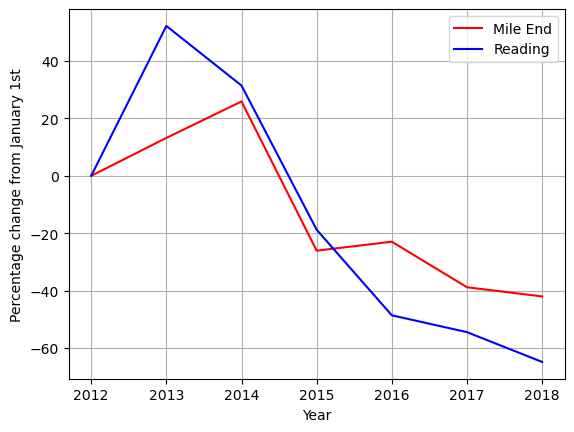

In [4]:
file = open('LaqnData-MileEnd_2010_2019.csv', 'r')
fileJan = open('LaqnData-MileEnd_2010_2019.csv', 'r')
headers = file.readline()
headers = fileJan.readline()

alldatesfinal = []
allvaluesfinal = []
weekdaysfinal = []
weekendsfinal = []
percentagefinalvalues = []

datesJan2012, valuesJan2012 = readDataByDate(fileJan, '01/01/2012 00:00', '31/01/2012 23:59', 'NOX')
weekdayJan2012, weekendJan2012 = averageByWeekMonthly(datesJan2012, valuesJan2012, 1, 2012)

datesfinal, valuesfinal = readDataByDate(file, '01/01/2012 00:00', '31/12/2018 23:59', 'NOX')
alldatesfinal.extend(datesfinal)
allvaluesfinal.extend(valuesfinal)

for j in range(7):    
    for i in range(1,13):
        weekdayfinal, weekendfinal = averageByWeekMonthly(alldatesfinal, allvaluesfinal, i, 2012)
        weekdaysfinal.append(weekdayfinal)
        weekendsfinal.append(weekendfinal)
    percentagefinal = ((weekdaysfinal[j] - weekdayJan2012)/weekdayJan2012)*100
    percentagefinalvalues.append(percentagefinal)
plt.plot(range(2012,2019), percentagefinalvalues, 'r-', label='Mile End')


fileR = open('LaqnData-Reading_2010_2019.csv', 'r')
fileJanR = open('LaqnData-Reading_2010_2019.csv', 'r')
headers = fileR.readline()
headers = fileJanR.readline()

alldatesfinalR = []
allvaluesfinalR = []
weekdaysfinalR = []
weekendsfinalR = []
percentagefinalvaluesR = []

datesJan2012R, valuesJan2012R = readDataByDate(fileJanR, '01/01/2012 00:00', '31/01/2012 23:59', 'NOX')
weekdayJan2012R, weekendJan2012R = averageByWeekMonthly(datesJan2012R, valuesJan2012R, 1, 2012)

datesfinalR, valuesfinalR = readDataByDate(fileR, '01/01/2012 00:00', '31/12/2018 23:59', 'NOX')
alldatesfinalR.extend(datesfinalR)
allvaluesfinalR.extend(valuesfinalR)

for j in range(7):    
    for i in range(1,13):
        weekdayfinalR, weekendfinalR = averageByWeekMonthly(alldatesfinalR, allvaluesfinalR, i, 2012)
        weekdaysfinalR.append(weekdayfinalR)
        weekendsfinalR.append(weekendfinalR)
    percentagefinalR = ((weekdaysfinalR[j] - weekdayJan2012R)/weekdayJan2012R)*100
    percentagefinalvaluesR.append(percentagefinalR)
plt.plot(range(2012,2019), percentagefinalvaluesR, 'b-', label='Reading')

plt.grid(True)
plt.xlabel('Year')
plt.ylabel('Percentage change from January 1st')  
plt.legend()